# 6. The full inference, start to finish

This notebook **is** `scripts/run_union21.py`, narrated. It imports that script
and calls its functions in order, so the numbers and the figures here are
literally the ones written to `results/` — there is no second copy of the
analysis code to drift out of step.

The steps:

1. load Union2.1 and build the posterior
2. warm up, then **freeze** the proposal
3. decide **how long** the chains have to be
4. run dispersed chains
5. report the constraints and check convergence
6. cross-check the analytic marginalization

Everything is driven by one seed.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPOSITORY = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPOSITORY / "scripts"))

import run_union21 as pipeline

pipeline._style()          # the same look the script uses
SEED = 20260908
rng = np.random.default_rng(SEED)

print("using", pipeline.__file__)

using /Users/hugodiniz/Documents/Projects/T1aSuper/scripts/run_union21.py


## 1. Data and posterior

The likelihood marginalizes the zero point $\mathcal{M}$ analytically, so the
sampled space is two-dimensional. The prior is the flat box from the exercise,
$0 \le \Omega_m \le 2$ and $-1 \le \Omega_\Lambda \le 3$.

In [2]:
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood
from snia.bayes.posterior import Posterior, UniformPrior
from snia.bayes.proposals import GaussianRandomWalk
from snia.bayes.samplers import run_chains

z, mu, cov = load_union21(systematics=True)
sigma = np.sqrt(np.diag(cov))

likelihood = Union21Likelihood(z, mu, cov)
posterior = Posterior(
    likelihood.log_likelihood,
    UniformPrior(pipeline.PRIOR_LOWER, pipeline.PRIOR_UPPER),
)

print(f"{z.size} supernovae, z from {z.min():.3f} to {z.max():.3f}")
print(f"log posterior at (0.3, 0.7) = {posterior([0.3, 0.7]):.3f}")

580 supernovae, z from 0.015 to 1.414
log posterior at (0.3, 0.7) = -272.561


## 2. Warm up, then freeze

A pilot chain with a crude diagonal proposal learns the *shape* of the
posterior. That covariance is then frozen: adapting while collecting samples
would break the Markov property and invalidate the chain.

In [3]:
tuned, centre, pilot_acceptance = pipeline.tune_proposal(posterior, 8000, rng)
proposal = GaussianRandomWalk(tuned, scale=pipeline.OPTIMAL_SCALE)

eigenvalues, eigenvectors = np.linalg.eigh(tuned)
print(f"pilot acceptance {pilot_acceptance:.3f}")
print("tuned covariance, now frozen:")
for row in tuned:
    print("   " + "  ".join(f"{value: .6f}" for value in row))
print(f"\ndegeneracy {np.sqrt(eigenvalues[1] / eigenvalues[0]):.1f} : 1"
      f"  along {eigenvectors[:, 1].round(2)}")

pilot acceptance 0.669
tuned covariance, now frozen:
    0.013482   0.021078
    0.021078   0.046340

degeneracy 4.2 : 1  along [0.44 0.9 ]


## 3. How many steps do the chains need?

Not guesswork. Since $P_0 = s_x^2\,\tau_{\rm int}$, the Dunkley ratio is exactly
the inverse effective sample size:

$$
r = \frac{P_0}{N s_x^{2}} = \frac{\tau_{\rm int}}{N} = \frac{1}{N_{\rm eff}},
\qquad
\frac{\rm MCSE}{s_x} = \sqrt{r} .
$$

So a target precision fixes the length:

$$
\boxed{\;N = \frac{\tau_{\rm int}}{r_{\rm target}}\;}
$$

$r < 0.01$ means the mean is known to a tenth of the posterior width; wanting
1% costs a hundred times more steps. The other Dunkley threshold is weaker:
for a random walk $k_\star \approx 2/\tau$, so $j_\star > 20$ needs only
$N > 20\pi\tau \approx 63\,\tau$. The $r$ condition binds first.

`calibrate_length` measures $\tau_{\rm int}$ with the **final** proposal — the
pilot used a deliberately crude one and would give the wrong answer.

In [4]:
recommended, tau_probe = pipeline.calibrate_length(
    posterior, proposal, centre, rng, target_r=0.01
)
print(f"tau_int on the calibration run : {tau_probe:.2f}")
for target in (0.01, 0.001):
    print(f"  N for r < {target:<6g} -> {int(np.ceil(tau_probe / target)):>8,} steps"
          f"   (MCSE = {100 * np.sqrt(target):.0f}% of the posterior width)")

tau_int on the calibration run : 6.73
  N for r < 0.01   ->      673 steps   (MCSE = 10% of the posterior width)
  N for r < 0.001  ->    6,727 steps   (MCSE = 3% of the posterior width)


In [5]:
# Check the rule: one long chain, cut to increasing lengths.
from snia.bayes.samplers import MetropolisHastings
from snia.diagnostics.spectral import fit_dunkley

long_chain = MetropolisHastings(posterior, proposal).sample(
    centre, 60000, np.random.default_rng(1)
)

print(f"{'N':>8} {'r fitted':>10} {'tau/N':>10}")
for n in (500, 1000, 2000, 5000, 10000, 20000, 40000, 60000):
    r = fit_dunkley(long_chain.samples[:n, 0]).r
    print(f"{n:8,} {r:10.5f} {tau_probe / n:10.5f}")

print(f"\nr first drops below 0.01 at N = 2,000;"
      f" the rule predicts {int(np.ceil(tau_probe / 0.01)):,}")

       N   r fitted      tau/N
     500    0.02432    0.01345
   1,000    0.00772    0.00673
   2,000    0.00421    0.00336
   5,000    0.00160    0.00135
  10,000    0.00079    0.00067
  20,000    0.00041    0.00034
  40,000    0.00021    0.00017


  60,000    0.00014    0.00011

r first drops below 0.01 at N = 2,000; the rule predicts 673


The fitted $r$ follows $\tau_{\rm int}/N$ over two decades, so the rule works — but it is not exact at the short end, where the crossing happens later
than predicted. On a short chain the spectral fit has few modes below the
turnover and comes out biased high, which is precisely what $j_\star > 20$ is
there to catch.

Treat $N = \tau_{\rm int}/r$ as a **floor** and allow a factor of a few. Below
we use 20 000 steps per chain, roughly 25 times the floor: it costs seconds and
buys $\mathrm{MCSE}/s \approx 1\%$ instead of 10%.

## 4. Dispersed chains

Chains that begin far apart and end up agreeing are much stronger evidence than
one stable-looking trace. These start at $3\sigma$ from the pilot, rejecting
any point where the posterior is not finite.

In [6]:
N_STEPS, N_CHAINS, BURN = 20000, 4, 2000

starts = pipeline.dispersed_starts(posterior, centre, tuned, N_CHAINS, rng)
production = run_chains(posterior, proposal, starts, N_STEPS, rng)
retained = production.burned(BURN)
samples = retained.samples

print("starting points:")
for start in starts:
    print("   " + "  ".join(f"{value: .4f}" for value in start))
print(f"\n{N_CHAINS} x {N_STEPS:,} steps, discarding {BURN:,} as burn-in")
print(f"burn-in is {BURN / tau_probe:.0f} correlation times, far more than needed")
print(f"{posterior.n_calls:,} posterior evaluations")

starting points:
    0.4224   1.2689
    0.0965   0.5881
    0.1682  -0.4171
    0.7542   1.3175

4 x 20,000 steps, discarding 2,000 as burn-in
burn-in is 297 correlation times, far more than needed
154,022 posterior evaluations


## 5. The constraints

`summarize` is the script's own reporting function, so this is verbatim what
lands in `results/summary.txt`.

In [7]:
pipeline.summarize(samples, likelihood, print)


--------------------------------------------------------------------------
CONSTRAINTS
--------------------------------------------------------------------------
parameter           mean       sd       16%       50%       84%
Omega_m           0.2814   0.1111    0.1666    0.2839    0.3922
Omega_Lambda      0.6637   0.2089    0.4507    0.6724    0.8748
Omega_k           0.0549   0.3081   -0.2579    0.0435    0.3725
q0               -0.5230   0.1652   -0.6895   -0.5297   -0.3555

accelerating (q0 < 0)          : 99.90% of the posterior
consistent with flat (|Ok|<.05): 12.58%
chi2 at the mean               : 545.14 for 580 SNe, chi2/dof = 0.9448
delta chi2 vs Einstein-de Sitter: 128.2
fitted zero point M            : 43.1734 mag -> H0 = 69.53


## 6. Convergence

In [8]:
converged = pipeline.report_convergence(
    samples, production.acceptance_rate, 0.01, print
)
print(f"\nall diagnostics passed: {converged}")


--------------------------------------------------------------------------
CONVERGENCE
--------------------------------------------------------------------------
acceptance per chain: [0.35  0.348 0.352 0.348]   (0.2-0.5 is healthy for a 2-D random walk)

parameter       tau_int      ESS      MCSE   MCSE/sd     Rhat  rank-Rhat
Omega_m            7.34     9809   0.00112    0.0101   1.0003     1.0004
Omega_Lambda       7.69     9366   0.00216    0.0103   1.0005     1.0005

  tau_int   steps before a sample is effectively independent
  ESS       independent-equivalent draws, pooled over all chains
  MCSE/sd   error on the mean as a fraction of the posterior width
  rank-Rhat between-chain agreement; must be < 1.01

Dunkley spectrum, per chain and parameter (unthinned):
parameter       chain        j*         r   alpha   verdict
Omega_m             0     692.4   0.00045    1.84   PASS
Omega_m             1     619.6   0.00047    1.69   PASS
Omega_m             2     782.7   0.00041    1.8

Omega_Lambda        0     575.4   0.00050    1.69   PASS


Omega_Lambda        1     625.4   0.00048    1.74   PASS
Omega_Lambda        2     742.5   0.00043    1.89   PASS
Omega_Lambda        3     688.8   0.00044    1.78   PASS

  thresholds: j* > 20 (white plateau resolved), r < 0.01 (mean precise)

Was the run long enough?
  measured tau_int (worst parameter) : 7.69
  N needed per chain for r < 0.01   : 769
  N actually used per chain          : 18,000  (23.4x)

rank-normalized Rhat < 1.01  : True
Dunkley thresholds passed  : True

all diagnostics passed: True


## 7. The figures

The same five figures the script writes to `results/`, produced by the same
functions.

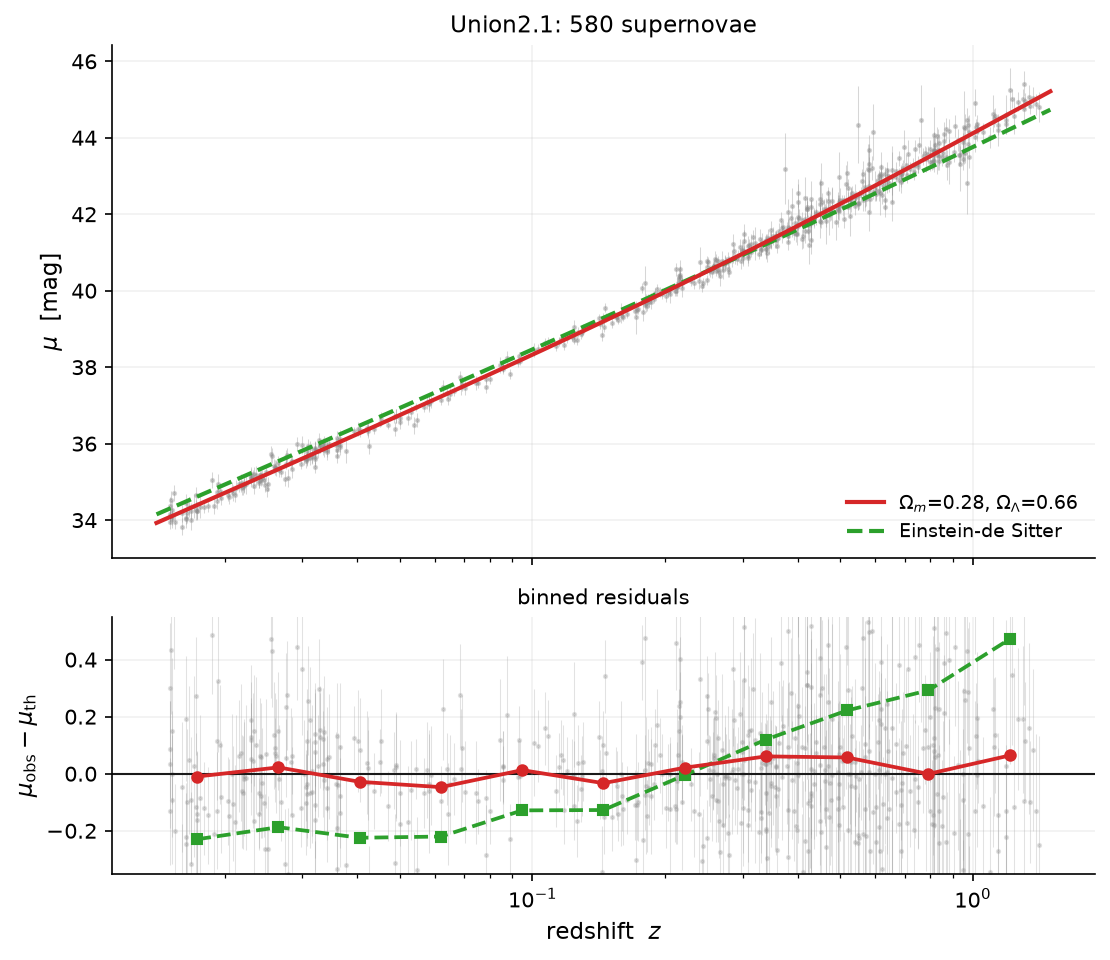

In [9]:
pipeline.figure_hubble(samples, likelihood, z, mu, sigma)
plt.show()

With its own best zero point, Einstein-de Sitter still drifts systematically
with redshift in the residual panel. That trend *is* the detection of
acceleration.

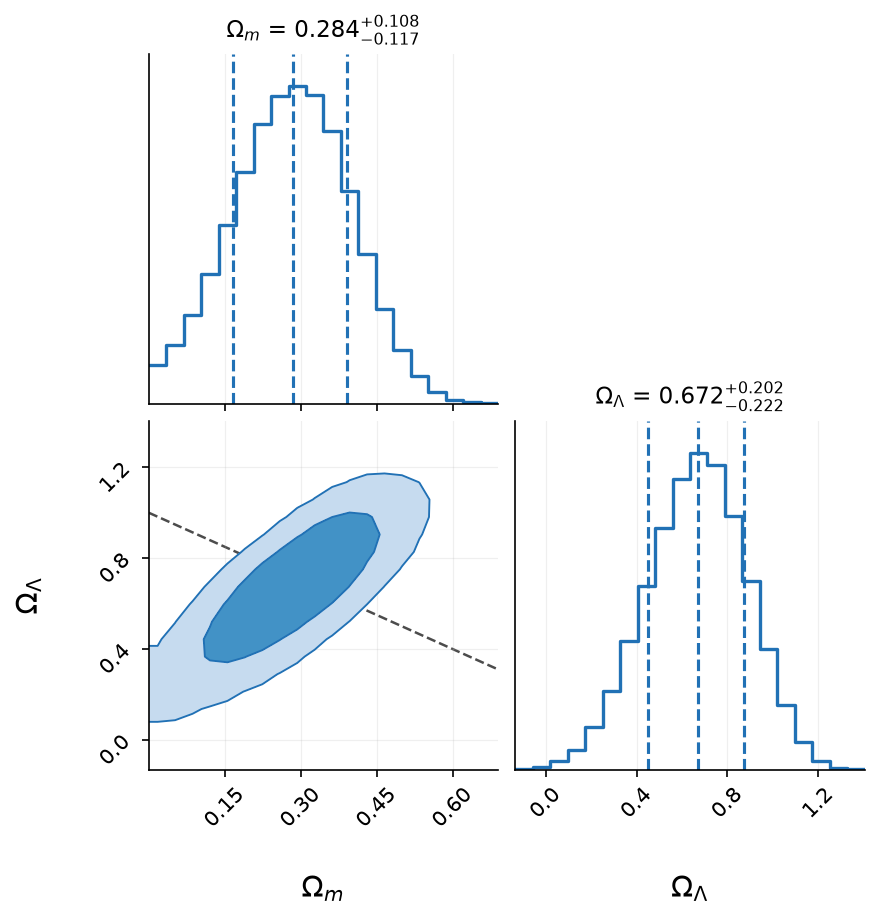

In [10]:
pipeline.figure_contours(samples)
plt.show()

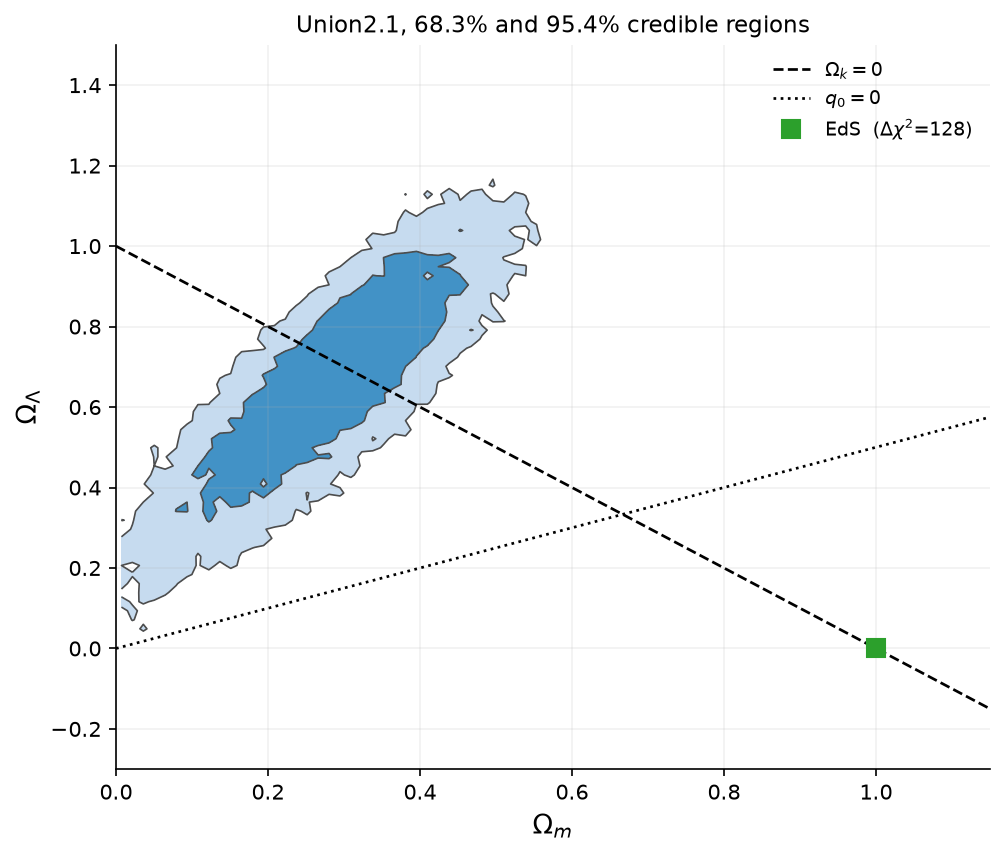

In [11]:
pipeline.figure_parameter_space(samples, likelihood)
plt.show()

The corner plot auto-scales to the posterior, which puts Einstein-de Sitter
off the edge; the second figure fixes the range so the comparison is visible.

The flat line runs straight through the allowed region: the data are consistent
with $\Omega_k = 0$ **without** it having been assumed. The contours are a long
narrow ellipse because supernovae constrain the combination
$q_0 = \Omega_m/2 - \Omega_\Lambda$ far better than either parameter alone —
which is why they are combined with the CMB or BAO, that cut the degeneracy at
a different angle.

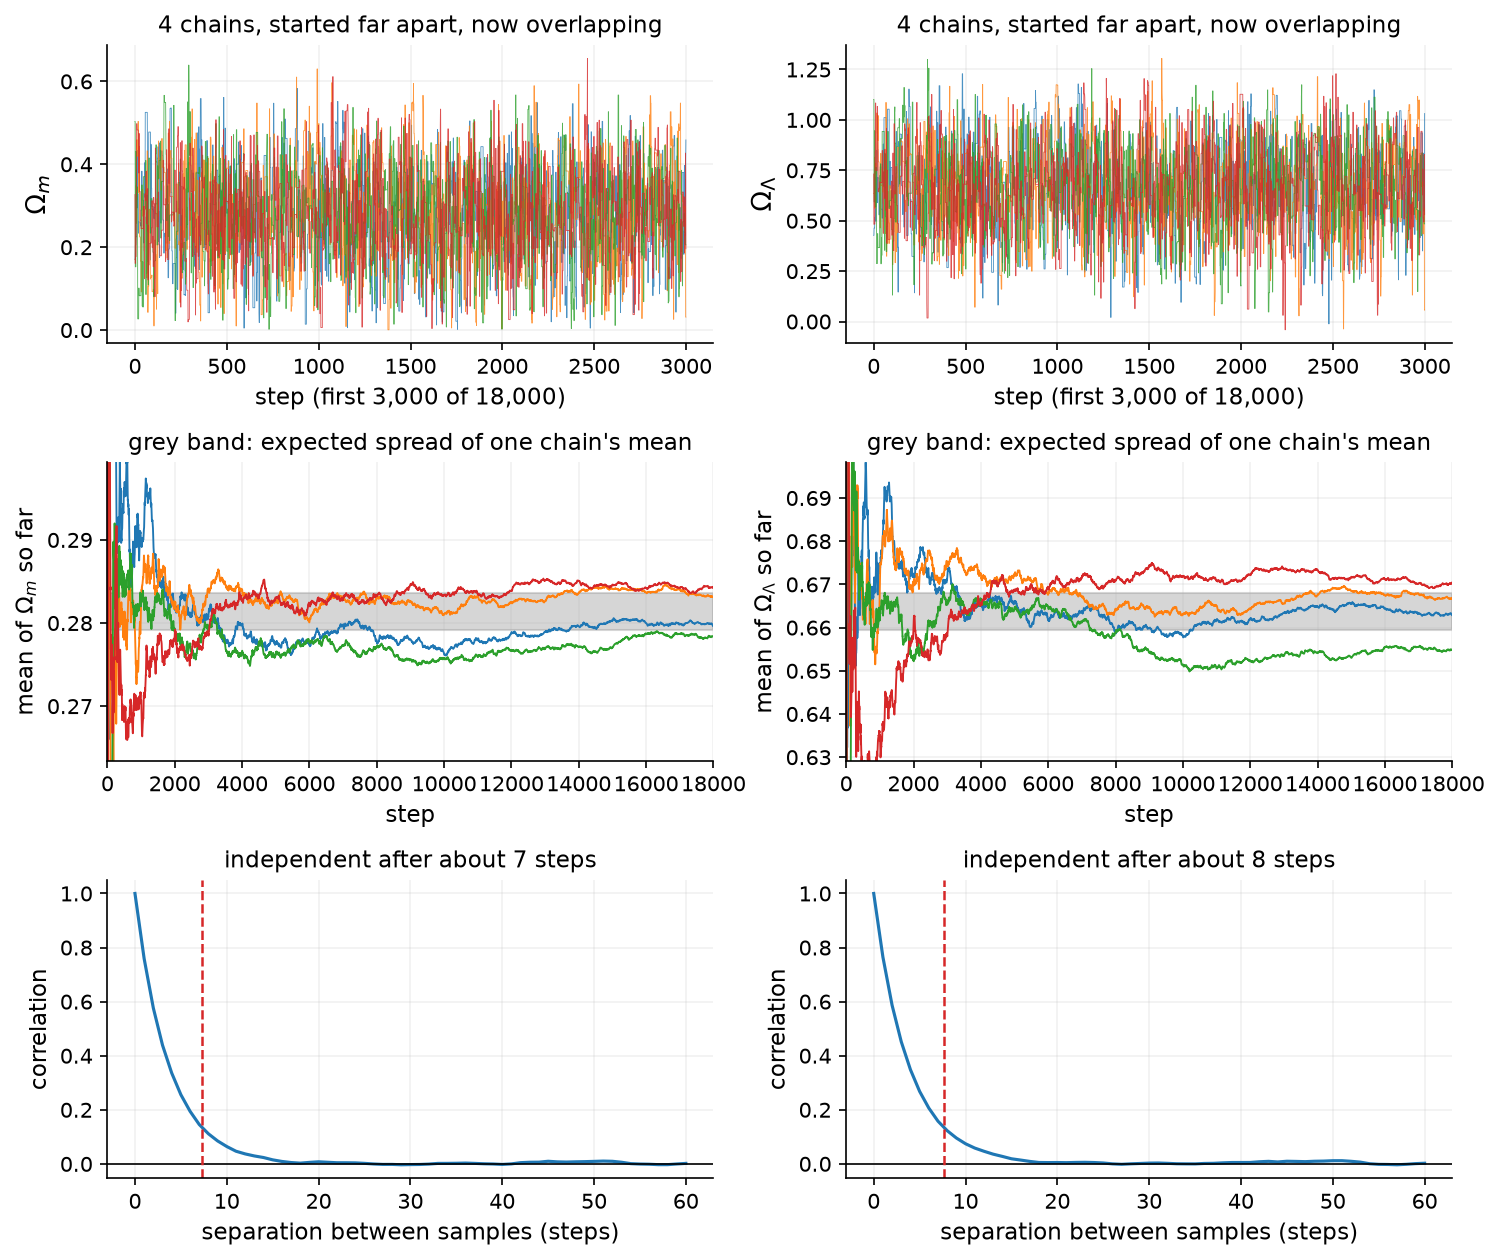

In [12]:
pipeline.figure_convergence(samples)
plt.show()

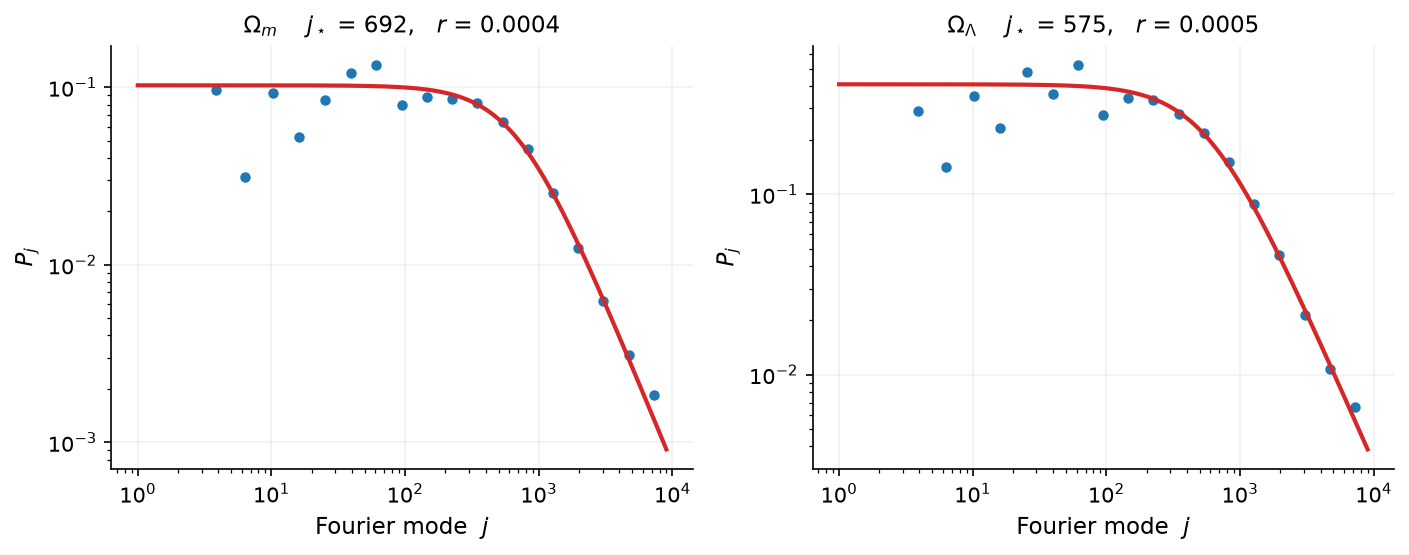

In [13]:
pipeline.figure_dunkley(samples)
plt.show()

## 8. Cross-check: sample $\mathcal{M}$ instead of marginalizing it

The analytic $\chi^2 = A - B^2/E$ assumes a flat prior on $\mathcal{M}$.
Sampling it as a third parameter must give the same $(\Omega_m, \Omega_\Lambda)$.
A sign error in $B$ would show up here and nowhere else.

In [14]:
pipeline.cross_check(
    likelihood, tuned, N_STEPS, rng,
    samples.reshape(-1, samples.shape[-1]), print,
)


--------------------------------------------------------------------------
CROSS-CHECK: M sampled instead of marginalized analytically
--------------------------------------------------------------------------
parameter                   analytic             M sampled     agreement
Omega_m           0.2814 +- 0.1111    0.2803 +- 0.1116     0.61 MCSE
Omega_Lambda      0.6637 +- 0.2089    0.6601 +- 0.2112     1.03 MCSE
M                 (marginalized out)   43.1739 +- 0.0329

A sign error in B, or a swapped residual convention, would separate
these. Nothing else in the pipeline would notice.


## 9. Does this agree with the published Union2.1 result?

The literature quotes the **flat** $\Lambda$CDM case, so that is what has to be
compared: fix $\Omega_\Lambda = 1 - \Omega_m$ and scan the one remaining
parameter, taking $\Delta\chi^2 = 1$ for the 68% interval.

Two independent things are worth checking, and neither is a free parameter of
ours:

* the **central value** against the published $\Omega_m$;
* the fitted zero point against $h = 0.7$. The release calibrated its fiducial
  $M_B$ on the statistics-only fit, so $\hat{\mathcal{M}}$ from *that* fit must
  invert to $H_0 = 70$ exactly. Nothing in our pipeline was tuned to make that
  happen, so it tests the whole chain at once: the loader, the dimensionless
  convention, and the marginalization.

In [15]:
grid = np.linspace(0.10, 0.60, 4001)

for label, use_systematics in [("with systematics", True), ("statistical only", False)]:
    zz, mm, cc = load_union21(systematics=use_systematics)
    like = Union21Likelihood(zz, mm, cc)
    chi2 = np.array([like.chi2((om, 1 - om)) for om in grid])
    best = grid[chi2.argmin()]
    inside = grid[chi2 < chi2.min() + 1.0]
    m_hat = like.m_offset((best, 1 - best))
    print(f"{label:20s} Omega_m = {best:.4f} "
          f"+{inside.max() - best:.4f} -{best - inside.min():.4f}"
          f"   chi2/dof = {chi2.min() / (zz.size - 2):.4f}"
          f"   H0 = {299792.458 / 10 ** ((m_hat - 25) / 5):.4f}")

print(f"\npublished, flat LCDM, SNe alone : Omega_m = 0.295 +- 0.032")
print(f"exact h = 0.7 zero point        : {25 + 5 * np.log10(299792.458 / 70):.5f} mag")

with systematics     Omega_m = 0.2955 +0.0424 -0.0394   chi2/dof = 0.9431   H0 = 69.6816


statistical only     Omega_m = 0.2776 +0.0197 -0.0191   chi2/dof = 0.9727   H0 = 70.0022

published, flat LCDM, SNe alone : Omega_m = 0.295 +- 0.032
exact h = 0.7 zero point        : 43.15861 mag


### Reading the comparison

The central value lands on the published one. The error bar is wider than the
$\pm0.032$ usually quoted, and that difference is **not** an artefact of how the
interval is defined — the profile $\Delta\chi^2 = 1$, the 1-D marginal
posterior from an MCMC, and the Gaussian curvature at the minimum all give the
same $\pm 0.041$. It sits between our statistics-only $\pm 0.019$ and our
statistics-plus-systematics $\pm 0.041$, so it reflects a different systematics
budget, not a different fit. Ours is the more conservative of the two.

The zero-point check is the sharper one, because it has no tolerance to hide
in: it comes out at $H_0 = 70.00$ km/s/Mpc from the statistics-only fit.

The full two-parameter result, with flatness **not** imposed, is in section 5
above; `scripts/run_union21.py --cross-check` reproduces all of it and writes
it to `results/`.